##Parâmetros da Simulação

In [59]:
import numpy as np
import random
K= 512 #tamanho da chave
L = 412  #tamanho da tag e da mensagem
N = int(10e3)
rho_s = np.sqrt(0.985)  # alocação de potência para a mensagem
snr_db = 10
eta = 0.01 #1% default

# Mensagem e Modulação BPSK#


In [60]:
#mensagem modulada de comprimento K com alfabeto de [1,-1]

def modulator_bpsk(K,num_msgs,seed=None):
    s_bin = [np.random.randint(0, 2, K) for _ in range(num_msgs)]
    s_bpsk = []
    # Modula os bits para BPSK: 0 → +1, 1 → −1
    for si in s_bin:
        s_bpsk.append(1 - 2 * si)  # equivalente a mapear 0→+1, 1→−1

    return s_bin, s_bpsk

#Geração das TAGs


In [61]:
a, b, c = 6, 1, 1
def Mfunc(x, K):
    return (a * x**2 + b * x + c) % (2**K)
#def tentmap(x):
#    if -1 <= x < 0:
#        return 2 * x + 0.9999
#    elif 0 <= x <= 1:
#        return -2 * x + 0.9999
#    else:
#        return 0  # fora do domínio esperado

def tentmap(x, beta=0.000001):
    if x == None: #condição inicial
        x = np.random.uniform(-1, 1) #escolhida aleatoriamente neste caso
    if x < beta:
        return 2/(beta+1)*x + (1-beta)/(beta+1) #~ 2x +1
    else:
        return 2/(beta-1)*x - (beta+1)/(beta-1) #~ 2x -1

def orbit(x0, steps):
    x = x0
    xorbit=[] #ponto inicial S0_(y)
    for i in range(steps):
        x = tentmap(x)
        xorbit.append(x)
    return xorbit

#def orbit_to_tag(orbit):
#    # Usa limiar em 0: x < 0 → -1, x ≥ 0 → +1
#    return np.array([1 if x >= 0 else -1 for x in orbit])

# Geração de TAG de comprimento L com 1 órbita por símbolo
def generate_tags(L, K, bits_msg, chaves):
    sigma = K - L  # pontos a descartar
    steps_total = K
    tags = []
    for bit, k in zip(bits_msg, chaves):
        #k_repeated = np.resize(k, L)
        m_filled = np.resize(bit,K) #extende a mensagem para o mesmo tamanho da chave
        s_xor_k = np.bitwise_xor(m_filled, k)

        # Converte vetor binário para inteiro
        xor_value = int("".join(str(b) for b in s_xor_k), 2)
        xi = Mfunc(xor_value, K=K)
        x0_norm =  (xi / (2**K - 1)) * 2 - 1  # normaliza para [-1, 1] # para que fique no alfabeto do mapa da tenda
        #gera orbita completa
        orb = orbit(x0_norm, K) # Iterar sigma + L vezes
        #print(orb)
        orb_descarte = orb[sigma:]  # descarta os sigma pontos
        #tag_symbol = orbit_to_tag(useful_tail)[0]  # pega o 1º dos L restantes
        tags.append(np.array(orb_descarte))
    tags0 = tags - np.mean(tags, axis=1, keepdims=True) # centraliza a media em 0

    return np.array(tags0)



In [62]:
chaves = [np.random.randint(0, 2, K) for _ in range(N)]
bits_msg, bpsk_msg = modulator_bpsk(L, N)
tags = generate_tags(L, K, bits_msg, chaves)

print("Media:", np.mean(tags))
print("Variancia :", np.var(tags))
print("Media do quadrado:", np.mean(tags**2))
tags

Media: -1.1813635291157004e-19
Variancia : 0.3323106509445898
Media do quadrado: 0.3323106509445898


array([[ 0.83411327, -0.65795003, -0.31932613, ..., -0.05068873,
         0.89519526, -0.78011414],
       [-0.22363258,  0.56830687, -0.18333378, ...,  0.74033901,
        -0.52739839, -0.03922414],
       [ 0.24729559,  0.37006316,  0.12452777, ...,  0.07887273,
         0.70690921, -0.54916501],
       ...,
       [-0.66784614, -0.34714059,  0.29426986, ...,  0.51006174,
         0.01422054,  1.00590392],
       [ 0.64611207, -0.30501579,  0.39423113, ..., -0.68822589,
        -0.37218829,  0.25988628],
       [-0.78636922, -0.59716414, -0.21875435, ..., -0.80277549,
        -0.62997663, -0.28437926]])

#Transmissão e Recepção#


In [63]:
#alocação de energia para tag e mensagem::
def compute_tag_energy(tag_array):
    # Garante lista de arrays
    energies = np.mean(tag_array**2)
    return energies  # média global dos valores quadraticos da tag

def combine_message_tag(s_list, tag_array, rho_s):
    Etags = compute_tag_energy(tag_array)  # E[tag^2]
    rho_t = np.sqrt((1 - rho_s**2)/Etags) #considerando que a energia da tag pode nao ser 1/3
    x_list = []
    for s, t in zip(s_list, tag_array):
        s = np.array(s)
        t = np.array(t)
        x = rho_s * s + rho_t * t
        x_list.append(x)

    return x_list, rho_t

def gen_noise(snr_db, len):
    snr_linear = 10**(snr_db / 10)
    Es= 1
    sigma2w = Es/ (2*snr_linear)  #energia fixa e conhecida. A SNR varia apenas com o ruido
    noise = np.random.normal(0, np.sqrt(sigma2w), len) #mesmo ruido da dissertacao
    return sigma2w, noise
# --- 7. Canal AWGN ---
def add_awgn(x_list, snr_db):

    y_list = []
    noise_list = []
    for x in x_list:
        sigma2w, noise = gen_noise(snr_db, len(x))
        y = x + noise
        y_list.append(y)
        noise_list.append(noise)
    return y_list, noise_list


#Teste de Hipótese

In [64]:
#criando a estatistica para a decisão
def detect_tag(y_list, s_list, tag_ref_list, rho_s, rho_t):
    stats = []
    for y, s, t_ref in zip(y_list, s_list, tag_ref_list):
        # Remove a contribuição da mensagem
        y_minus_msg = (y - rho_s * s)/rho_t

        # Correlação com TAG legítima (esperada)
        stat = np.sum(y_minus_msg*t_ref)
        stats.append(stat)

    return np.array(stats)


In [65]:
#decisão
#H1: tag presente
#H0: sem tag
def simulate_hypothesis_test(L, K, N, rho_s, snr_db, messages, bits_all, chaves):
    # TAGs legítimas (H1)
    tags_legit = generate_tags(L, K, bits_all, chaves)
    x_legit, rho_t = combine_message_tag(messages, tags_legit, rho_s)
    y_legit, noise = add_awgn(x_legit, snr_db)

    # Sem tag, adicionando ruído a mensagem apenas (H0)
    #tags_fake = generate_false_tags(L, N, seed=24)
    #x_fake, _ = combine_message_tag(messages, tags_fake, rho_s)
    y_notags, noise = add_awgn(messages, snr_db)

    # Detector
    stat_legit = detect_tag(y_legit, messages, tags_legit, rho_s, rho_t)
    stat_fake = detect_tag(y_notags, messages, tags_legit, rho_s, rho_t) #mantendo a remoção da mensagem pra a mensagem sem tag também
    #stat_fake = []
    #for y, t_ref in zip(y_notags, tags_legit):
        # Correlação com TAG legítima (esperada)
    #    stat = np.sum(y*t_ref)
    #    stat_fake.append(stat)

    return np.array(stat_legit).flatten(), np.array(stat_fake).flatten()


#Matriz de Confusão e Limiar de decisão

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def compute_confusion_matrix(stat_H1, stat_H0, threshold):
    # Gera os rótulos verdadeiros
    y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])

    # Gera os rótulos preditos com base no limiar
    y_scores = np.concatenate([stat_H1, stat_H0])
    y_pred = (y_scores >= threshold).astype(int)
    # Calcula matriz de confusão
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()

    print(f"Threshold: {threshold}")
    print(f"TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")
    print(f"Accuracy: {(TP + TN) / len(y_true):.3f}")
    print(f"False Positive Rate: {FP / (FP + TN):.3f}")
    print(f"False Negative Rate: {FN / (FN + TP):.3f}")

    # Exibe a matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["H0", "H1"])
    disp.plot(cmap='Blues', values_format='d')
    plt.grid(False)
    plt.title("Matriz de Confusão")
    plt.show()


In [67]:
#Decodificador da dissertação:
from scipy.stats import norm
from scipy.special import erfc
import pytest

def Qfunc(x):
    """ Q function """
    return (0.5)*erfc(x/np.sqrt(2))

def thresh(stdDev,mean,alpha):
#    """ Finds the decision threshold for the hypothesis test """
    threshold = 0
    while Qfunc((threshold-mean)/stdDev) > alpha:
        threshold += 0.1
    return threshold
#def thresh(stdDev, mean, alpha):
#    return norm.isf(alpha) * stdDev + mean

#def thresh(std, mean, alpha):
#    return mean + std * norm.isf(alpha)

def tauVarCalc(sigma2w,len_message,rho_t, tags):
    #tag_array = [np.array(t) for t in tags]
    #var_tags = [np.var(t) for t in tag_array]  # variancia por TAG
    sigma2tag = np.var(tags) #deve ser igual a media dos valores quadraticos, pra bater com a energia da tag calculada acima
    #assert sigma2tag == compute_tag_energy(tags), "Mismatch energy and var"
    #assert abs(sigma2tag - compute_tag_energy(tags)) < 1e-5
    tauVar = (sigma2tag*sigma2w*len_message)/(rho_t**2)
    return tauVar

def threshold_decision(stat_legit, stat_fake, sigma2w, len_message, rhot,tags, eta):
    """
    Decide entre H1 (TAG legítima) e H0 (sem TAG ou falsa),
    com base no limiar calculado pela expressão:
    Q(tau_i / sigma^2_vi) < eta
    """
    sigma2_v = tauVarCalc(sigma2w,len_message, rho_t,tags)
    # Encontrar o menor τ_0 tal que Q(τ_0 / σ²_vi) < η
    tau0 = thresh(np.sqrt(sigma2_v), 0, eta)
    return tau0


##Simulação

Threshold: 141.19999999999627
TP: 3764, FP: 0, TN: 10000, FN: 6236
Accuracy: 0.688
False Positive Rate: 0.000
False Negative Rate: 0.624


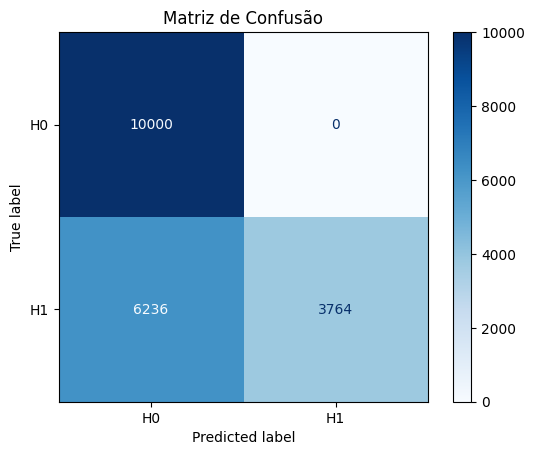

Limiar medio: 141.2000


In [68]:
sigma2w, noise = gen_noise(snr_db, len(bpsk_msg)) # calcula a variancia do ruido inserido na mensagem
Etags = compute_tag_energy(tags)
rho_t = np.sqrt((1 - rho_s**2) / Etags)

stat_H1, stat_H0 = simulate_hypothesis_test(L, K, N, rho_s, snr_db, bpsk_msg, bits_msg, chaves) #extrai tag ruidosa e calcula correlação com a tag verdadeira, na visao da recepção de quem tem a chave
tau0 = threshold_decision(stat_H1,stat_H0, sigma2w, len(bpsk_msg), rho_t, tags,eta)
# Decisões
compute_confusion_matrix(stat_H1, stat_H0, tau0)
print(f"Limiar medio: {tau0:.4f}")


#Segunda opcao de threshold (empírico e otimizado)



Melhor threshold para FP ≤ 1.0%: 28.8921
TPR (sensibilidade): 100.00%
FPR (falso positivo): 1.00%
Threshold: 28.89214039698785
TP: 10000, FP: 100, TN: 9900, FN: 0
Accuracy: 0.995
False Positive Rate: 0.010
False Negative Rate: 0.000


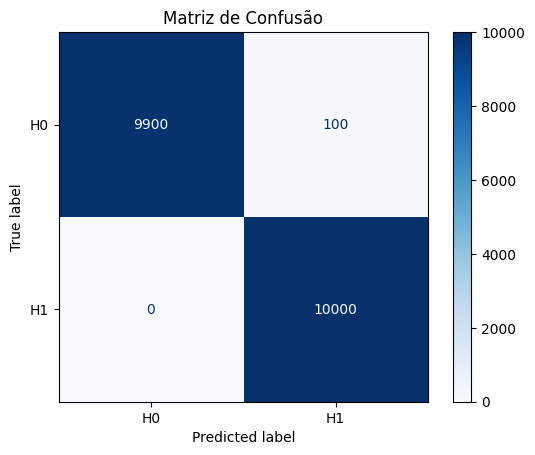

In [69]:
import numpy as np

def find_threshold_to_reduce_fp(stat_H1, stat_H0, eta):
    # Concatenar todos os scores para possíveis thresholds
    all_scores = np.sort(np.concatenate([stat_H1, stat_H0]))

    best_threshold = None
    best_tp = 0
    best_fp = 1.0  # começa alto

    for tau in all_scores:
        tp = np.sum(stat_H1 >= tau) / len(stat_H1)
        fp = np.sum(stat_H0 >= tau) / len(stat_H0)

        # Queremos FP <= target_fp_rate e maior TP possível
        if fp <= eta and tp > best_tp:
            best_tp = tp
            best_fp = fp
            best_threshold = tau

    print(f"Melhor threshold para FP ≤ {eta*100}%: {best_threshold:.4f}")
    print(f"TPR (sensibilidade): {best_tp*100:.2f}%")
    print(f"FPR (falso positivo): {best_fp*100:.2f}%")

    return best_threshold
threshold = find_threshold_to_reduce_fp(stat_H1, stat_H0, eta)
compute_confusion_matrix(stat_H1, stat_H0, threshold)

##Trade-offs

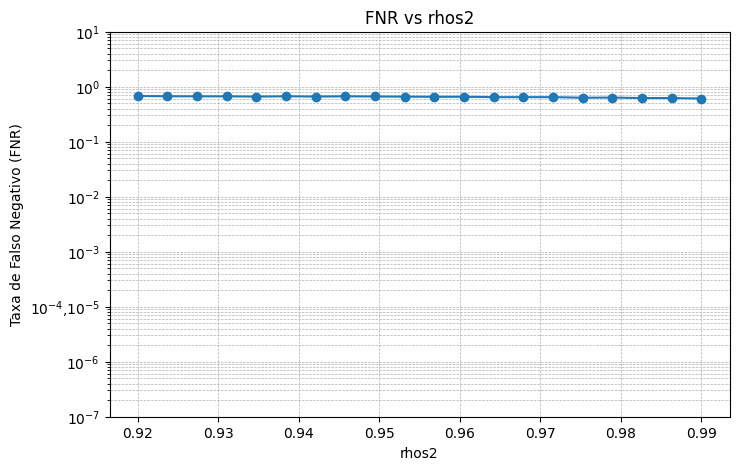

In [70]:
from matplotlib.ticker import LogLocator, FormatStrFormatter
def plot_fnr_vs_rhos2(L_max, K, N, snr_db, bpsk_msg, bits_msg, chaves,tags, eta):
    """
    Plota a taxa de falso negativo (FNR) em função de rhos2.

    Parâmetros:
        L_max (int): comprimento máximo da tag.
        stat_H1_func (callable): função que gera estatísticas para H1 dados L.
        stat_H0_func (callable): função que gera estatísticas para H0 dados L.
        threshold_func (callable): função que retorna o limiar (threshold) dado L.
    """
    #rhos2_values = [0.985, 0.98714286, 0.98928571, 0.99142857, 0.99357143,
    #                0.99571429, 0.99785714, 1.] #linspace de 0.92 a 1.0
    rhos2_values = np.linspace(0.8, 0.99, num=20)
    fnr_values = []

    for rhos2 in rhos2_values:
        # Gera amostras para hipótese H1 (tag legítima) e H0 (não legítima)
        stat_H1, stat_H0 = simulate_hypothesis_test(L_max, K, N, np.sqrt(rhos2), snr_db, bpsk_msg, bits_msg, chaves)
        Etags = compute_tag_energy(tags)
        rho_t = np.sqrt((1 - rhos2) / Etags)
        sigma2w, noise = gen_noise(snr_db, len(bpsk_msg))
        tau0 =  threshold_decision(stat_H1, stat_H0, sigma2w, len(bpsk_msg), rho_t,tags, eta)
        #tau0 = find_threshold_to_reduce_fp(stat_H1, stat_H0, eta)

        # Falso negativo: quando H1 é rejeitado
        #fnr = np.mean(stat_H1 < tau0)
        fnr = np.sum(stat_H1 < tau0)/len(stat_H1)
        fnr_values.append(fnr)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(rhos2_values, fnr_values, marker='o')
    # Configura escala logarítmica no eixo Y
    plt.yscale('log', base=10)

    # Define os ticks principais nas potências de 10 desejadas
    ticks = [10**i for i in range(1, -7, -1)]  # [1, 0.1, 0.01, 0.001, 0.0001]

    plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('10$^{%d}$'))

    # Ajusta os ticks para os valores desejados e formatacao customizada
    plt.yticks(ticks, [r'$10^{1}$',r'$10^{0}$', r'$10^{-1}$', r'$10^{-2}$',r'$10^{-3}$',r'$10^{-4}$,'r'$10^{-5}$',r'$10^{-6}$',r'$10^{-7}$'])
    plt.xlabel("rhos2")
    plt.ylabel("Taxa de Falso Negativo (FNR)")
    plt.title("FNR vs rhos2")
    #plt.ylim(1e-2, 1e0)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

plot_fnr_vs_rhos2(L, K, N, snr_db, bpsk_msg, bits_msg, chaves,tags, eta)

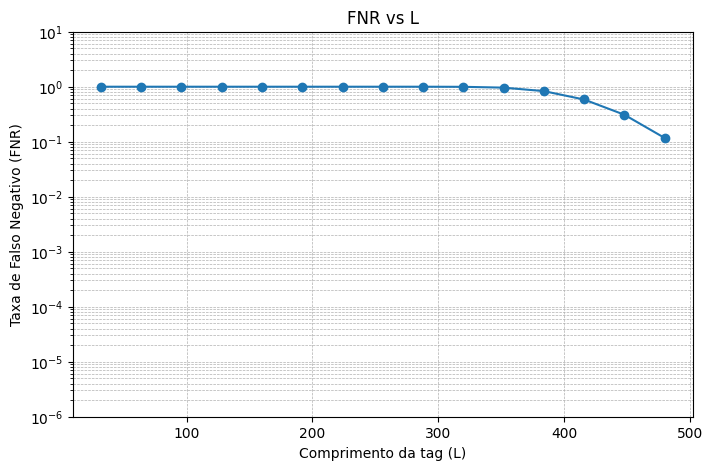

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter

def plot_fnr_vs_L(K, N, snr_db, bpsk_msg, bits_msg, chaves, eta,rho_s):
    """
    Plota a taxa de falso negativo (FNR) em função do comprimento da tag L.

    Parâmetros:
        L_max (int): comprimento máximo da tag.
    """
    L_max = K
    L_values = np.arange(32, L_max, 32)  # Valores de L de 32 até L_max, passo de 32
    fnr_values = []

    for L in L_values:
        # Gera amostras para hipótese H1 (tag legítima) e H0 (não legítima)
        bits_msg, bpsk_msg = modulator_bpsk(L, N)
        tags = generate_tags(L, K, bits_msg, chaves)
        stat_H1, stat_H0 = simulate_hypothesis_test(L, K, N, rho_s, snr_db, bpsk_msg, bits_msg, chaves)
        Etags = compute_tag_energy(tags)
        rho_t = np.sqrt((1 - 0.95) / Etags)  # fixei rhos2=0.95 (ajuste se quiser variar junto)
        sigma2w, noise = gen_noise(snr_db, len(bpsk_msg))

        # Limiar
        tau0 = threshold_decision(stat_H1, stat_H0, sigma2w, len(bpsk_msg), rho_t, tags, eta)

        # Falso negativo: quando H1 é rejeitado
        fnr = np.sum(stat_H1 < tau0) / len(stat_H1)
        fnr_values.append(fnr)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(L_values, fnr_values, marker='o')

    # Configura escala logarítmica no eixo Y
    plt.yscale('log', base=10)

    # Define os ticks principais nas potências de 10 desejadas
    ticks = [10**i for i in range(1, -7, -1)]  # [10^1, 10^0, 10^-1, ..., 10^-7]

    plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('10$^{%d}$'))

    # Ajusta ticks manualmente para exibir os expoentes no formato bonito
    plt.yticks(
        ticks,
        [r'$10^{1}$', r'$10^{0}$', r'$10^{-1}$', r'$10^{-2}$', r'$10^{-3}$', r'$10^{-4}$', r'$10^{-5}$', r'$10^{-6}$']
    )

    plt.xlabel("Comprimento da tag (L)")
    plt.ylabel("Taxa de Falso Negativo (FNR)")
    plt.title("FNR vs L")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()
plot_fnr_vs_L(K, N, snr_db, bpsk_msg, bits_msg, chaves, eta, rho_s)

In [72]:
#rho_s = np.sqrt(0.985)  # alocação de energia para a mensagem
#snr_db = 10  # SNR do canal
# Combinação a ser transmitida
#x_list, rho_t = combine_message_tag(bpsk_msg, tags, rho_s)
# Canal AWGN
#y_list, noise = add_awgn(x_list, snr_db) #sinal recebido
#print(len(x_list))
#print(rho_t)

In [73]:
#Calculo de TNR
#def compute_tnr(rho_t, sigma_w2, Etags):
    #all_tags = np.concatenate(tag_list)
    #E_tag = np.sum(all_tags ** 2)
#    tnr = (rho_t ** 2) * Etags / sigma_w2
#    return tnr


In [74]:
'''#def generate_false_tags(L, N, seed=None):
#    rng = np.random.default_rng(seed)
#    # Gera N tags falsas de comprimento L, com valores reais entre -1 e 1
#    return [rng.uniform(-1, 1, size=L) for _ in range(N)]

def generate_false_tags(L, N, seed=None):
    rng = np.random.default_rng(seed)
    tags = []
    for _ in range(N):
        tag = rng.uniform(-1, 1, size=L)  # valores aleatórios entre -1 e 1
        tag0_fake = tag - np.mean(tag)               # força média zero
        tags.append(np.array(tag0_fake))

    return np.array(tags)  # vetor de vetores (shape: N x L) com cada tag tendo media zero'''


'#def generate_false_tags(L, N, seed=None):\n#    rng = np.random.default_rng(seed)\n#    # Gera N tags falsas de comprimento L, com valores reais entre -1 e 1\n#    return [rng.uniform(-1, 1, size=L) for _ in range(N)]\n\ndef generate_false_tags(L, N, seed=None):\n    rng = np.random.default_rng(seed)\n    tags = []\n    for _ in range(N):\n        tag = rng.uniform(-1, 1, size=L)  # valores aleatórios entre -1 e 1\n        tag0_fake = tag - np.mean(tag)               # força média zero\n        tags.append(np.array(tag0_fake))\n\n    return np.array(tags)  # vetor de vetores (shape: N x L) com cada tag tendo media zero'